# Machine Learning 지도학습 - 분류


## ⚙️환경설정


In [20]:
# scikit-learn 설치
!pip install scikit-learn -q

In [10]:
import sklearn
sklearn.__version__

'1.9.0'

In [17]:
# 라이브러리와 한글 폰트 설정
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = None

for font_name in font_candidates.get(platform.system(), []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
if selected_font:
    sns.set_theme(style="whitegrid", rc={"font.family": selected_font, "axes.unicode_minus": False})

설정된 한글 폰트: Malgun Gothic


## 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>


In [12]:
# 도미와 빙어의 길이/무게 원자료

# 도미 bream 데이터 35개
# bream_length: 도미 35마리의 길이
# bream_weight: 도미 35마리의 무게
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어 smelt 데이터 14개
# smelt_length: 빙어 14마리의 길이
# smelt_weight: 빙어 14마리의 무게
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

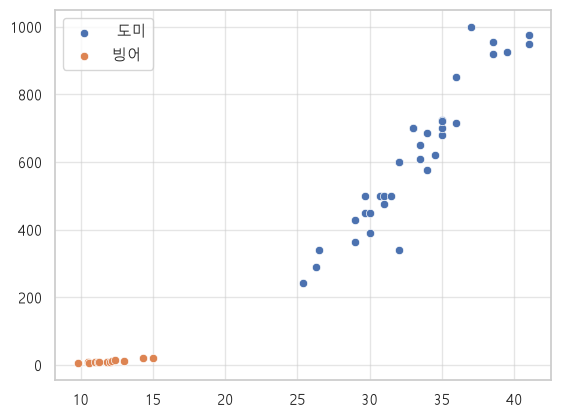

In [13]:
# 산점도표를 이용해서 도미와 빙어의 분포를 확인
sns.scatterplot(
    x=bream_length, y=bream_weight, label=' 도미'
)

sns.scatterplot(
    x=smelt_length, y=smelt_weight, label='빙어'
)

plt.legend()
plt.show()

## KNN K-최근접이웃분류모델
데이터포인트간의 거리기반으로 분류를 수행하는 모델


### k-최근접 이웃 알고리즘 작동원리

최근접이웃(K-Nearest Neighbors, KNN)에서 거리를 구하는 방법으로 가장 일반적으로 사용되는 방법은 **유클리드 거리(Euclidean distance)**이다.

유클리드 거리란 "두 점 사이의 직선 거리" 를 구하는 가장 간단한 방법이다.

좌표상 (0, 0)과 (3, 4)라는 점 두 개를 찍었다고 하자. 이 두 점을 선으로 연결하면, 바로 그 선의 길이가 유클리드 거리이다!

$$\text { 거리 }=\sqrt{\left(x_{2}-x_{1}\right)^{2}+\left(y_{2}-y_{1}\right)^{2}}$$

두 점 $p = (p_1, p_2, ..., p_n)$과 $q = (q_1, q_2, ..., q_n)$ 사이의 유클리드 거리는 다음과 같은 수식으로 계산된다.

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}$$

#### 다양한 거리계산법
이 외에도 거리 계산에 사용하는 방법에는 **맨해튼 거리(Manhattan distance)**, **민코프스키 거리(Minkowski distance)**, **코사인 유사도(Cosine similarity)** 등이 있다.

1. 맨해튼 거리 계산식:

$$d(p, q) = |p_1 - q_1| + |p_2 - q_2| + \cdots + |p_n - q_n|$$

2. 민코프스키 거리 계산식(유클리드와 맨해튼 거리를 일반화한 형태):
  (여기서 $p = 2$일 때는 유클리드 거리, $p = 1$일 때는 맨해튼 거리이다)
$$d(p, q) = \left( \sum_{i=1}^{n} |p_i - q_i|^p \right)^{1/p}$$

3. 코사인 유사도:
  (여기서 $p \cdot q$는 두 벡터의 내적, $\|p\|$와 $\|q\|$는 벡터의 크기이다)
$$\cos \theta = \frac{p \cdot q}{\|p\| \|q\|}$$



In [14]:
# 도미와 빙어 데이터를 모델 입력용 데이터 X로 변환

# 도미와 빙어의 길이, 무게 list를 이어붙이기
fish_length = bream_length + smelt_length # 35 + 14 = 49개
fish_weight = bream_weight + smelt_weight

print(len(fish_length), len(fish_weight))

fish_data = [[length, weight] for length, weight  in zip(fish_length, fish_weight)]

fish_data = np.array(fish_data)
fish_data


49 49


array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [15]:
# fish_data에 대응되는 정답 y 만들기
# 앞에 도미 35마리를 1, 뒤에 빙어 14마리 0으로 지정
fish_target = np.array([1]*35 + [0]*14)
fish_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [27]:
# KNeighborsClassifier  - KNN 분류 모델
# KNN은 새 데이터가 입력되면 가장 가까운 학습 데이터 이웃을 찾고,
# 그 이웃들의 정답을 다수결로 사용해 새 데이터의 클래스를 판별함
from sklearn.neighbors import KNeighborsClassifier

# 입력된 값과 가장 가까운 이웃 5개를 보고 판별할 분류 모델 객체 생성
kn_clf = KNeighborsClassifier(n_neighbors=5)

KNeighborsClassifier()

| 항목 | 의미 |
|---|---|
| `n_neighbors = 5` | 가장 가까운 이웃 5개를 보고 판단 |
| `weights = 'uniform'` | 이웃 5개의 투표 가중치를 똑같이 적용 |
| `algorithm = 'auto'` | 가까운 이웃을 찾는 방법은 scikit-learn이 자동 선택 |
| `p = 2` | 거리 계산에서 유클리드 거리 사용 |
| `metric = 'minkowski'` | 민코프스키 거리 사용, `p=2`라서 사실상 유클리드 거리 |
| `n_jobs = None` | 병렬 처리 별도 지정 안 함 |

| 항목 | 의미 |
|---|---|
| `classes_ = [0, 1]` | 이 모델이 배운 정답 종류는 0과 1 |
| `n_features_in_ = 2` | 입력 feature는 2개, 즉 길이와 무게 |
| `n_samples_fit_ = 49` | 학습에 사용한 생선 데이터는 49개 |
| `outputs_2d_ = False` | 정답 `y`가 2차원이 아니라 1차원이라는 뜻 |

In [28]:
# KNN 분류 모델에 fish_data, fish_target 학습 시키기
# 모델.fit(X, y) - X == 데이터(문제), y == 정답
kn_clf.fit(fish_data, fish_target)

KNeighborsClassifier()

In [30]:
# score()를 통해 분류 모델의 학습 정확도 점수를 반환(0 ~ 1 우수)

# - 학습에 사용한 데이터를 그대로 평가에 사용 == 당연히 1
kn_clf.score(fish_data, fish_target)

1.0

In [33]:
# 학습된 데이터 말고 새로운 데이터를 전달

# predict() : 학습된 모델로 새 데이터의 정답을 예측하는 메서드
# - 입력은 반드시 2차원의 형태
# sample[0] == 도미 , sample[1] == 빙어
sample = [ [40, 500],  [10, 10], [11.3, 20], [15,200] ]
kn_clf.predict(sample)  # [1, 0]으로 예측


array([1, 0, 0, 1])

In [49]:
# 새 데이터와 가장 가까운 이웃(이미 학습된 데이터) 찾기
# kneighbors(new, n_neighbors=k) : 새 데이터와 가장 가까운 이웃 k개 찾기
# 반환값 distances: 새 데이터와 가까운 이웃 사이의 거리
# 반환값 indices: 가까운 이웃들이 학습 데이터(fish_Data)
#                몇 번째 인덱스에 있는지 나타냄
distances, indices = kn_clf.kneighbors([[20,170]], n_neighbors=5)
print("distances: ", distances)
print("indices: ", indices)

fish_target[indices] # 이웃 목록 - 1(도미), 0(빙어)

distances:  [[ 72.20221603 120.1652612  150.18325473 150.408045   156.78431044]]
indices:  [[ 0  1 48 47 45]]


array([[1, 1, 0, 0, 0]])

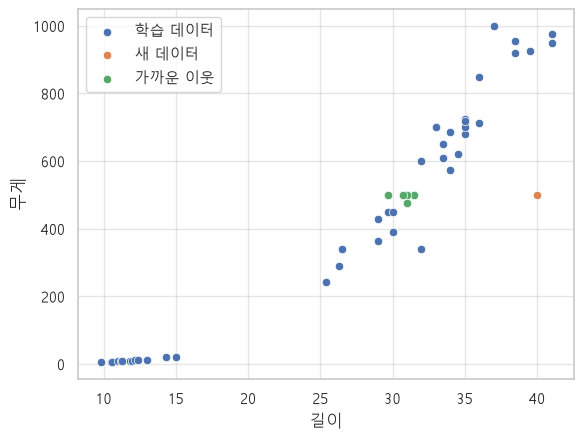

In [55]:
# 최근접 이웃을 시각화(산점도)
sns.scatterplot(
    x=fish_data[:, 0], # 물고기 길이
    y=fish_data[:, 1], # 물고기 무게
    label = '학습 데이터'
)

# 새 데이터(예측하려는 데이터)를 그래프에 표시
sns.scatterplot(x=[40], y=[500], label="새 데이터")

distances, indices = kn_clf.kneighbors([[40,500]], n_neighbors=5)

# 새 데이터와 가까운 이웃한 데이터의 인덱스를 5개 반환
# print(indices.squeeze())
neighbor_indices = indices.squeeze()

# 가까운 이웃한 데이터를 그래프에 표시
sns.scatterplot(
    x = fish_data[neighbor_indices, 0], # 이웃 물고기의 길이
    y = fish_data[neighbor_indices, 1], # 이웃 물고기의 무게
    label = "가까운 이웃"
)

plt.xlabel("길이")
plt.ylabel("무게")
plt.show()


## 학습/테스트 세트 분리


In [57]:
# 모든 데이터를 학습용 사용 X
# 일부는 학습, 일부는 테스트

# train_test_split(): 입력 X와 정답 y를 학습용/테스트용으로 분리
from sklearn.model_selection import train_test_split
(X_train, X_test, y_train, y_test) = train_test_split(
    fish_data,    # X(문제)
    fish_target,  # y(답)
    test_size = 0.2, # 전체 데이터 중 20%를 테스트용, 나머지 80% 학습용
    stratify=fish_target, # 도미, 빙어의 train/test 비율을 맞춤
    random_state=42
)

print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)


X_train:  (39, 2)
X_test:  (10, 2)
y_train:  (39,)
y_test:  (10,)


In [66]:
# 1. 다시 KNN 분류 모델 생성
kn_clf = KNeighborsClassifier() # n_neighbors=5 기본값

# 2. 학습: X_train, y_train 만 학습
kn_clf.fit(X_train, y_train)

# 3. 평가: X_test, y_test로 평가 점수 확인
print("테스트 점수:", kn_clf.score(X_test, y_test))

# 4. 예측: X_test를 모델에 전달할 경우 얻는 예측값을 y_test와 비교
print("예측: ", kn_clf.predict(X_test))
print("정답: ", y_test)

테스트 점수: 1.0
예측:  [1 0 1 1 0 1 1 1 0 1]
정답:  [1 0 1 1 0 1 1 1 0 1]


## 수상한 도미
도미(길이 25, 무게 150)의 문제


In [67]:
kn_clf.predict([[25, 150]])
# 실행 결과: array([0]) == KNN 모델이 0(빙어)으로 예측

array([0])

[[150.2675072  150.27996089 150.3795216  150.4543032  150.48510969]] [[30 35  4 15 24]]
[[1 1 1 1 1]]


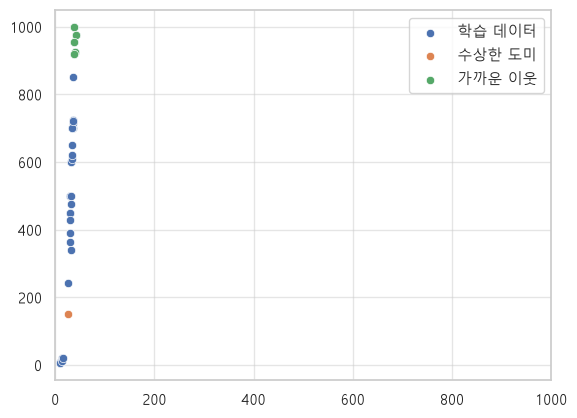

In [84]:
# 도미 데이터를 넣었는데 빙어로 예측하는 원인을 그래프로 확인
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], label='학습 데이터')
sns.scatterplot(x=[25], y=[150], label='수상한 도미')

# '수상한 도미'와 가장 가까운 이웃의 거리와 X_train 인덱스를 반환
distances, indices = kn_clf.kneighbors([[25, 150]])
print(distances, indices)

# 반환된 X_train 인덱스에 대응되는 정답 y_train 출력
print(y_train[indices])

neighbor_indices = indices.squeeze()
sns.scatterplot(
    x=X_train[neighbor_indices, 0],
    y=X_train[neighbor_indices, 1],
    label='가까운 이웃',
)

# x축 범위를 y축과 비슷하게 큰 값으로 설정하면
# 분포가 함축되어 보여 구분하기가 쉬워진다! -> KNN에서 스케일링이 필요한 이유!!
plt.xlim((0, 1000))
plt.legend()
plt.show()

## 표준점수-스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리기법.
모델 성능에 직접적인 영향이 있음.


###  표준점수로 환산하기
표준점수(또는 Z-점수)는 데이터가 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 나타낸 값이다.

$Z = \frac{X - \mu}{\sigma}$

-   $X$는 데이터 값
-   $\mu$는 데이터의 평균
-   $\sigma$는 데이터의 표준편차

특성값에서 평균을 빼고, 표준편차로 나누기.


In [77]:
# 사이킷런 제공 스케일링용 전처리 클래스
# -> 각 feature(X)를 표준점수 z-score로 바꿔주는 전처리기
from sklearn.preprocessing import StandardScaler

sclaer = StandardScaler()
# 학습용/테스트용 입력 데이터(X)를 표준점수(z-score) 스케일링
# fit_transform(): 훈련 데이터의 평균/표준편차를 학습하고, 그 기준으로 X_train을 변환
# transform():  훈련 데이터에서 학습한 평균/표준편차를 그대로 사용해 X_test를 변환
X_train_scaled = sclaer.fit_transform(X_train)
X_test_scaled = sclaer.transform(X_test)

# 스케일링된 데이터를 fit() XXXXXXX
# -> 스케일링 안된 데이터 + 스케일링된 데이터 -> 학습 데이터가 엉망진창(누수)
# -> 대신 학습 데이터를 치환(변환) transform(X) 이용

print(X_test)
print(X_test_scaled)
# -> 데이터가 몰려있는 모습을 확인

[[ 26.3 290. ]
 [ 11.8  10. ]
 [ 34.  685. ]
 [ 31.  500. ]
 [ 12.4  13.4]
 [ 26.5 340. ]
 [ 35.  680. ]
 [ 34.  575. ]
 [ 11.    9.7]
 [ 41.  950. ]]
[[-0.09416558 -0.50278807]
 [-1.53337188 -1.35834417]
 [ 0.6701026   0.70415714]
 [ 0.37233578  0.13887901]
 [-1.47381852 -1.34795528]
 [-0.07431445 -0.35001019]
 [ 0.76935821  0.68887936]
 [ 0.6701026   0.36804582]
 [-1.61277637 -1.35926084]
 [ 1.36489185  1.51387988]]


In [79]:
# 새 KNN 분류 모델 만들어서 스케일링된 데이터로 재학습
kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train_scaled, y_train)
print("테스트 점수: ", kn_clf.score(X_test_scaled, y_test))

테스트 점수:  1.0


In [80]:
# 수상한 도미[25,150] 데이터를 스케일링된 데이터를 학습한 모델에게 전달
# -> 수상한 도미[25,150]를 스케일링하여 전달!!
q = sclaer.transform([[25, 150]]) # z-score로 치환
print(q)
kn_clf.predict(q) # 스케일링 전 == 0,  스케일링 후 == 1

[[-0.22319787 -0.93056612]]


array([1])

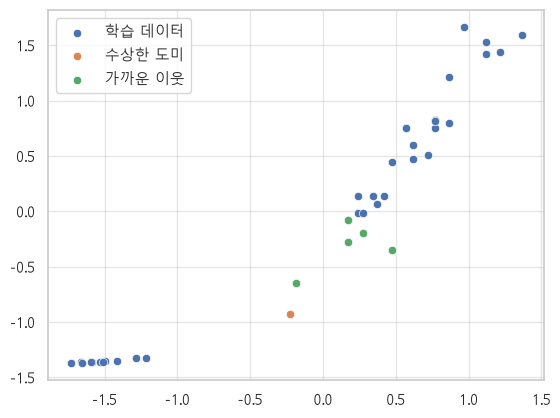

In [82]:
# 스케일링된 데이터를 이용한 시각화
# X_train_scaled[:, 0]: 스케일링된 길이
# X_train_scaled[:, 1]: 스케일링된 무게
sns.scatterplot(x=X_train_scaled[:, 0], y=X_train_scaled[:, 1], label='학습 데이터')

sns.scatterplot(x=q[:, 0], y=q[:, 1], label='수상한 도미')

distances, indices = kn_clf.kneighbors(q)
neighbor_indices = indices.squeeze()

sns.scatterplot(
    x=X_train_scaled[neighbor_indices, 0],
    y=X_train_scaled[neighbor_indices, 1],
    label='가까운 이웃',
)

plt.legend()
plt.show()

# 생선 다중분류

| Fish      | Korean Name | Image | Avg Size |
|-----------|-------------|-------|----------|
| Bream     | 도미        | <img src="https://d.pr/i/FaQ4RH+" alt="Bream" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Roach     | 붕어        | <img src="https://d.pr/i/C8jz9h+" alt="Roach" width="300px"> | 평균 길이 20~30cm *(일반적인 붕어 기준)* |
| Whitefish | 흰물고기    | <img src="https://d.pr/i/5z0jBB+" alt="Whitefish" width="300px"> | 평균 길이 30~50cm *(종류에 따라 다름)* |
| Parkki    | 파키        | <img src="https://d.pr/i/CcYfbX+" alt="Parkki" width="300px"> | 평균 길이 15~20cm *(일반적인 파키 기준)* |
| Perch     | 농어        | <img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Pike      | 강꼬치고기  | <img src="https://d.pr/i/NNWlsh+" alt="Pike" width="300px"> | 평균 길이 40~55cm, 최대 1m 이상<br>*(북방강꼬치고기 기준)* |
| Smelt     | 빙어        | <img src="https://d.pr/i/NmXwPX+" alt="Smelt" width="300px"> | 평균 길이 10~15cm *(빙어 기준)* |


**참고 및 설명**
- 도미(Bream)는 대표적으로 참돔을 기준으로 하였으며, 평균 길이 50~60cm, 최대 1m까지 자랍니다.
- 농어(Perch)는 실제로는 Perch(배스)와 농어(Seabass)가 다르나, 표 내 농어는 평균 50~60cm, 최대 1m 이상까지 자랍니다.
- 붕어(Roach), 파키(Parkki), 빙어(Smelt) 등은 한국 내 일반적인 평균 크기를 참고하였습니다.
- 흰물고기(Whitefish), 강꼬치고기(Pike)는 여러 종류가 있으나, 대표적인 종의 평균 크기를 기재했습니다.



In [86]:
# 데이터셋 불러오기
fish_df = pd.read_csv("data/fish.csv")
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [87]:
# 데이터셋에 종 별로 몇 마리씩 있는지 확인
fish_df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [88]:
# 다중 분류 모델에 학습 시킬 입력 X, 정답 y를 분리
# X: 물고기의 수치 컬럼 5개를 담은 2차원 ndarray
# y: 각 물고기의 종류 Species 담은 1차원 ndarray
X = fish_df[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
y = fish_df['Species'].to_numpy()
print(X.shape, y.shape)

(159, 5) (159,)


In [90]:
# 다중 분류 train/test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(X, y, stratify=y, random_state=42))
    # test_size=0.25가 기본값

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(119, 5) (119,)
(40, 5) (40,)


In [91]:
# 입력 값 X의 데이터 단위를 표준화 -> 스케일링
from sklearn.preprocessing import StandardScaler
sclaer = StandardScaler()

# 스케일러에게 입력 값 X를 학습 -> 내부적으로 평균, 표준편차가 계산됨
sclaer.fit(X_train)

# 학습 데이터와 test 데이터를 같은 평균/표준편차를 이용해 스케일링
X_train_scaled = sclaer.transform(X_train)
X_test_scaled  = sclaer.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-7.56288032e-01 -6.60656767e-01 -6.23574459e-01 -7.80151591e-01
  -4.50436444e-01]
 [-4.59910572e-01 -1.24845300e-01 -2.44146026e-01 -4.29348704e-01
   3.51691877e-02]
 [ 7.35688553e-02  2.12851003e-02  2.16588499e-01  7.95412076e-01
   3.74817965e-01]
 [ 1.54063728e+00  1.04419790e+00  1.23743166e+00  2.29283234e+00
   1.34130358e+00]
 [-8.74839016e-01 -7.58077034e-01 -8.22322686e-01 -8.06729366e-01
  -5.69714299e-01]
 [-6.16990626e-01 -3.09943807e-01 -4.15792222e-01 -6.00632966e-01
  -1.60556561e-01]
 [-9.93390000e-01 -1.10878999e+00 -1.18368310e+00 -1.06882893e+00
  -9.36700077e-01]
 [ 8.73787997e-01  4.10966168e-01  6.23118963e-01  1.38724215e+00
   4.12802638e-01]
 [-4.00635080e-01 -2.22265567e-01 -2.08009985e-01 -2.24652384e-01
  -1.54873814e-01]
 [-4.83620769e-01 -3.29427860e-01 -1.44771913e-01  5.76145440e-01
  -2.91558819e-01]
 [-8.60020143e-01 -7.58077034e-01 -8.22322686e-01 -7.53336516e-01
  -7.17764796e-01]
 [ 1.52581841e+00  9.46777635e-01  1.12902354e+00  2.12261594e+00

In [100]:
# KNN 다중 분류 학습
from sklearn.neighbors import KNeighborsClassifier

# 가까운 이웃 3개를 보고 정답을 예측(다수결)
kn_clf = KNeighborsClassifier(n_neighbors=3)

# 학습
kn_clf.fit(X_train_scaled, y_train)

# kn_clf.get_params()
print(kn_clf.classes_)
print(kn_clf.n_neighbors)
print(kn_clf.n_samples_fit_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
3
119


In [104]:
# 모델이 학습한 데이터에 대한 점수, 예측
print("학습 점수: ", kn_clf.score(X_train_scaled, y_train))
print("테스트 평가 점수: ", kn_clf.score(X_test_scaled, y_test))

print("예측: ", kn_clf.predict(X_test_scaled))
print("정답: ", y_test)

학습 점수:  0.8823529411764706
테스트 평가 점수:  0.75
예측:  ['Perch' 'Perch' 'Roach' 'Parkki' 'Parkki' 'Roach' 'Perch' 'Pike' 'Bream'
 'Perch' 'Pike' 'Roach' 'Bream' 'Perch' 'Perch' 'Bream' 'Perch' 'Bream'
 'Pike' 'Roach' 'Bream' 'Roach' 'Perch' 'Roach' 'Pike' 'Perch' 'Roach'
 'Smelt' 'Perch' 'Smelt' 'Bream' 'Bream' 'Bream' 'Parkki' 'Smelt' 'Roach'
 'Perch' 'Perch' 'Bream' 'Perch']
정답:  ['Roach' 'Perch' 'Perch' 'Parkki' 'Parkki' 'Perch' 'Perch' 'Pike' 'Bream'
 'Roach' 'Pike' 'Perch' 'Bream' 'Perch' 'Perch' 'Bream' 'Roach' 'Bream'
 'Pike' 'Perch' 'Bream' 'Roach' 'Perch' 'Perch' 'Pike' 'Perch' 'Whitefish'
 'Smelt' 'Smelt' 'Smelt' 'Bream' 'Bream' 'Bream' 'Parkki' 'Smelt' 'Roach'
 'Perch' 'Perch' 'Bream' 'Perch']


In [106]:
# KNN이 학습 후 어떤 정보를 가지고 있나 확인
print(kn_clf.classes_)

print(kn_clf._fit_X) # 학습 입력 데이터 X

print(kn_clf._y) # 학습 정답 데이터 y

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[-7.56288032e-01 -6.60656767e-01 -6.23574459e-01 -7.80151591e-01
  -4.50436444e-01]
 [-4.59910572e-01 -1.24845300e-01 -2.44146026e-01 -4.29348704e-01
   3.51691877e-02]
 [ 7.35688553e-02  2.12851003e-02  2.16588499e-01  7.95412076e-01
   3.74817965e-01]
 [ 1.54063728e+00  1.04419790e+00  1.23743166e+00  2.29283234e+00
   1.34130358e+00]
 [-8.74839016e-01 -7.58077034e-01 -8.22322686e-01 -8.06729366e-01
  -5.69714299e-01]
 [-6.16990626e-01 -3.09943807e-01 -4.15792222e-01 -6.00632966e-01
  -1.60556561e-01]
 [-9.93390000e-01 -1.10878999e+00 -1.18368310e+00 -1.06882893e+00
  -9.36700077e-01]
 [ 8.73787997e-01  4.10966168e-01  6.23118963e-01  1.38724215e+00
   4.12802638e-01]
 [-4.00635080e-01 -2.22265567e-01 -2.08009985e-01 -2.24652384e-01
  -1.54873814e-01]
 [-4.83620769e-01 -3.29427860e-01 -1.44771913e-01  5.76145440e-01
  -2.91558819e-01]
 [-8.60020143e-01 -7.58077034e-01 -8.22322686e-01 -7.53336516e-01
  -7.17764796e-01]
 [ 

In [107]:
print(X_test_scaled.shape)

(40, 5)


In [114]:
# print(X_test_scaled[:5])  # X_test_scaled 0~4번행

# 테스트데이터 앞 5행만 예측하고 정답과 비교
print(kn_clf.predict(X_test_scaled[:5]))
print(y_test[:5])

['Perch' 'Perch' 'Roach' 'Parkki' 'Parkki']
['Roach' 'Perch' 'Perch' 'Parkki' 'Parkki']


In [118]:
# 예측 확률 확인
kn_clf.predict_proba(X_test_scaled[:5])

array([[0.        , 0.        , 0.66666667, 0.        , 0.33333333,
        0.        , 0.        ],
       [0.        , 0.        , 0.66666667, 0.        , 0.33333333,
        0.        , 0.        ],
       [0.        , 0.        , 0.33333333, 0.        , 0.66666667,
        0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.66666667, 0.        , 0.        , 0.33333333,
        0.        , 0.        ]])

In [125]:
# 다중 분류에서 kneighbor()로 예측 근거가 된 이웃 찾기
distances, indices = kn_clf.kneighbors(X_test_scaled[:1])  # X_test_scaled[0]
print(X_test_scaled[0])
print(distances)
print(indices)

print(y_train[indices])

[-0.84520127 -0.75807703 -0.71391456 -0.70656438 -0.72566082]
[[0.08963266 0.11925561 0.12001498]]
[[100  10 117]]
[['Roach' 'Perch' 'Perch']]


## @실습문제: 붓꽃 다중 분류

붓꽃은 세포핵을 둘러싼 꽃받침(sepal)과 꽃잎(petal)으로 구성되어 있으며, 이러한 특징을 기반으로 붓꽃의 품종을 식별할 수 있습니다.

- Setosa (세토사): Setosa는 붓꽃 중에서 가장 작은 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎과 꽃받침이 비교적 짧고 뾰족한 모습을 갖고 있으며, 주로 흰색 또는 연한 분홍색을 띠고 있습니다.

- Versicolor (버시컬러): Versicolor는 Setosa보다 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 보통 연한 보라색이며, 중간 크기의 붓꽃입니다.

- Virginica (버지니카): Virginica는 붓꽃 중에서 가장 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 주로 짙은 보라색이며, 다른 품종들에 비해 상대적으로 더 큰 크기를 갖고 있습니다.

![](https://d.pr/i/4egoon+)


In [132]:
# scikit-learn에서 iris 데이터셋 얻어오기
from sklearn.datasets import load_iris

iris = load_iris()
# print(iris.data) # 입력 X
# print(iris.target) # 정답 y
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [134]:
iris_df = pd.DataFrame(
    iris.data, #  X
    columns=iris.feature_names
)

iris_df['target'] = iris.target

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [138]:
# 1. train/test split
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,    # 입력 X
    iris.target,  # 정답 y
    stratify=iris.target,
    random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# 2. 스케일링
scaler = StandardScaler()
scaler.fit(X_train) # X_train기준 평균, 표준편차 학습

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3. KNN 분류 모델 생성 + 학습 fit()
kn_clf = KNeighborsClassifier(n_neighbors=3)
kn_clf.fit(X_train_scaled, y_train)

# 4. 평가  score()
print("학습 데이터셋 평가 : ", kn_clf.score(X_train_scaled, y_train))
print("테이스 데이터셋 평가 : ", kn_clf.score(X_test_scaled, y_test))

# 5. 예측 predict() - test 데이터 일부와, 실제 정답을 비교
print("예측: ", kn_clf.predict(X_test_scaled[:5]))
print("정답: ", y_test[:5])

(112, 4) (112,)
(38, 4) (38,)
학습 데이터셋 평가 :  0.9642857142857143
테이스 데이터셋 평가 :  0.9210526315789473
예측:  [0 1 1 1 0]
정답:  [0 1 1 1 0]
